## Data Preprocessing & Cleaning

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

!pip install xgboost


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)

intrusions = pd.read_csv('cybersecurity_intrusion_data.csv')
intrusions.shape

(9537, 11)

### Display first few rows

In [2]:
intrusions.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


### Drop Unnecessary column 'browser_type'

In [3]:
intrusions = intrusions[['network_packet_size', 'protocol_type', 'login_attempts', 'session_duration',
                         'encryption_used', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']]

### Check for missing values

In [4]:
print("\nMissing Values in Each Column:")
print(intrusions.isna().sum())


Missing Values in Each Column:
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
unusual_time_access       0
attack_detected           0
dtype: int64


### Fill missing values in 'encryption_used'

In [5]:
intrusions['encryption_used'] = intrusions['encryption_used'].fillna('None')

<ipython-input-5-62b7c2cd898f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intrusions['encryption_used'] = intrusions['encryption_used'].fillna('None')


### Check for duplicates and remove them

In [6]:
intrusions.drop_duplicates(inplace=True)

<ipython-input-6-5ff28647ccee>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intrusions.drop_duplicates(inplace=True)


### Convert categorical data

In [7]:
intrusions = pd.get_dummies(intrusions, columns=['protocol_type', 'encryption_used'], drop_first=True)

### Verify dataset structure

In [8]:
print("\nUpdated Dataset Structure:")
intrusions.info()


Updated Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   network_packet_size   9537 non-null   int64  
 1   login_attempts        9537 non-null   int64  
 2   session_duration      9537 non-null   float64
 3   ip_reputation_score   9537 non-null   float64
 4   failed_logins         9537 non-null   int64  
 5   unusual_time_access   9537 non-null   int64  
 6   attack_detected       9537 non-null   int64  
 7   protocol_type_TCP     9537 non-null   bool   
 8   protocol_type_UDP     9537 non-null   bool   
 9   encryption_used_DES   9537 non-null   bool   
 10  encryption_used_None  9537 non-null   bool   
dtypes: bool(4), float64(2), int64(5)
memory usage: 558.9 KB


## Exploratory Data Analysis

### Check Attack Rates

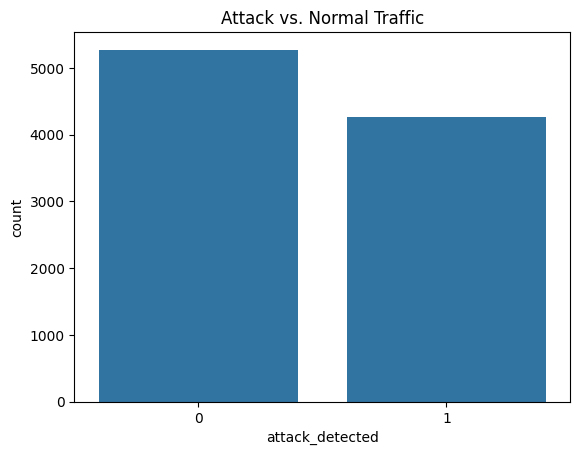

In [9]:
sns.countplot(x='attack_detected', data=intrusions)
plt.title('Attack vs. Normal Traffic')
plt.show()

### Check Feature Distriutions

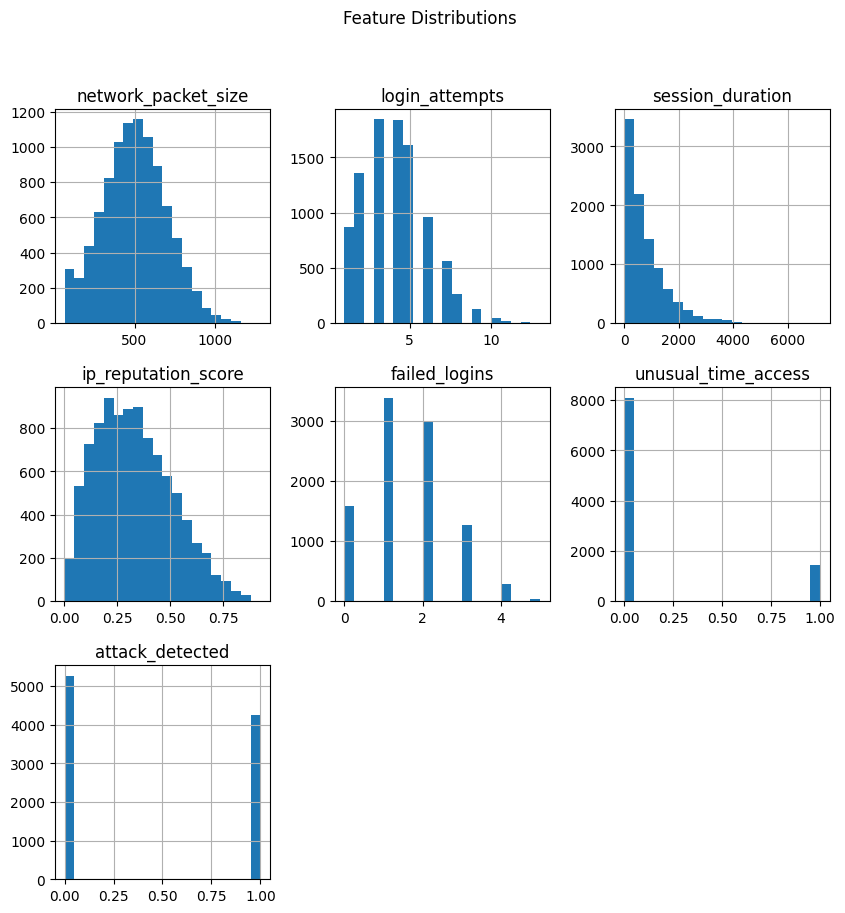

In [10]:
intrusions.hist(figsize=(10, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.show()

### Check Feature Correlations

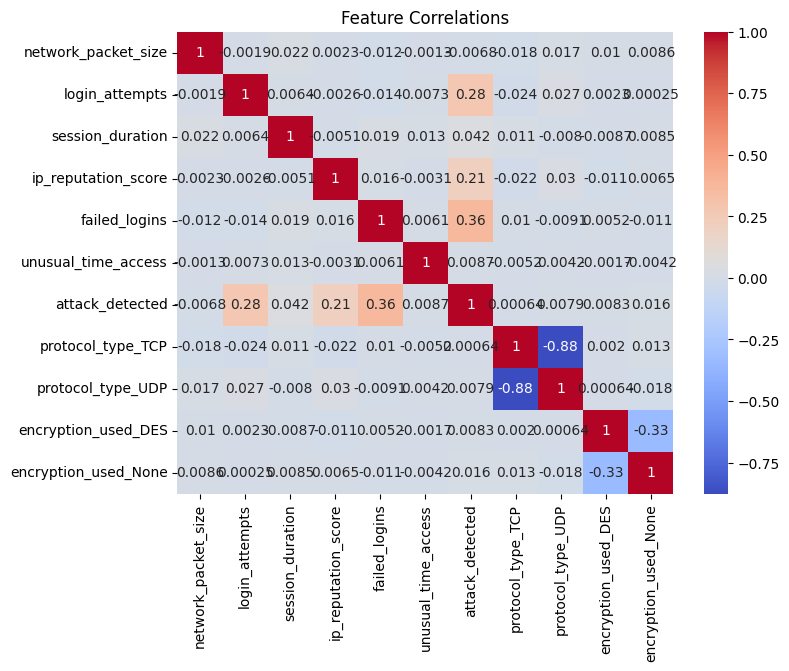

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(intrusions.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

## Split Data into Train & Test Sets

In [12]:
from sklearn.model_selection import train_test_split

# Define features and target
X = intrusions.drop(columns=['attack_detected'])
y = intrusions['attack_detected']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

Training data: (7629, 10), Testing data: (1908, 10)


## Train Random Forest Model

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Initialize and train

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=12)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=12)

### Make predictions

In [15]:
y_pred = model.predict(X_test)


### Evaluate performance

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8679
Precision: 0.9858
Recall: 0.7194
F1 Score: 0.8318


## Model Performance
### Current Recall: 72% (Misses 28% of attacks)
### Improve recall to detect more attacks - prefer false positive than false negatives
### Use XGBoost + Hyperparameter tuning

## Feature Importance Analysis

In [17]:
importance = model.feature_importances_
feature_names = X.columns

### Plot Feature Importance

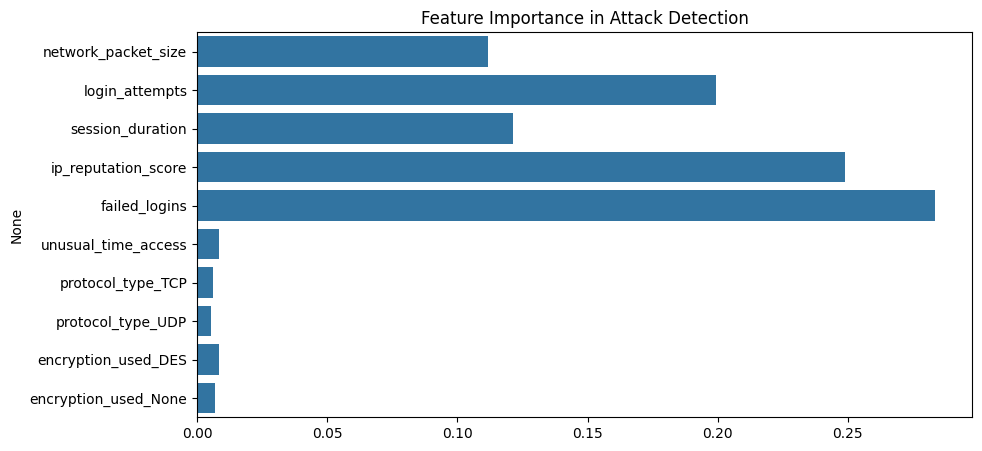

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(x=importance, y=feature_names)
plt.title('Feature Importance in Attack Detection')
plt.show()


## Train XGBoost

In [19]:
model = XGBClassifier(scale_pos_weight=(sum(y_train == 0) / sum(y_train ==1)), random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### Make predictions

In [20]:
y_pred = model.predict(X_test)

### Evaluate performance

In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8595
Precision: 0.9410
Recall: 0.7367
F1 Score: 0.8264


## Hyperparamter Tuning Using GridSearchCV

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3]
}

grid_search = GridSearchCV(XGBClassifier(scale_pos_weight=(sum(y_train == 0) / sum(y_train == 1)), random_state=42),
                           param_grid, scoring = 'recall', cv=3, verbose =2)


### Train the model using GridSearch

In [23]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=6, n_es

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 6, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)

### Print best parameters

In [24]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 300}


## Train XGBoost with the Best Parameters

In [25]:
best_params = grid_search.best_params_

In [26]:
best_model = XGBClassifier(**best_params, scale_pos_weight=(sum(y_train == 0) / sum(y_train == 1)), random_state=42)
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### Make predictions again

In [27]:
y_pred_best = best_model.predict(X_test)

### Evaluate new model

In [28]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Best Model Performance")
print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1 Score: {f1_best:.4f}")

Best Model Performance
Accuracy: 0.8475
Precision: 0.9032
Recall: 0.7436
F1 Score: 0.8157


## Lower Threshold & Recalculate Recall

### Prioritize detecting real attacks even if some normal traffic is mistakenly flagged.

In [29]:
y_probs = best_model.predict_proba(X_test)[:, 1]

### Adjust threshold from 0.5 to 0.3

In [30]:
y_pred_lower_threshold = (y_probs >= 0.3).astype(int)

### Recalculate Recall

In [31]:
new_recall = recall_score(y_test, y_pred_lower_threshold)
new_precision = precision_score(y_test, y_pred_lower_threshold)
new_f1 = f1_score(y_test, y_pred_lower_threshold)

print("\nLowered Threshold Performance:")
print(f"Recall: {new_recall:.4f}")
print(f"Precision: {new_precision:.4f}")
print(f"F1 Score: {new_f1:.4f}")


Lowered Threshold Performance:
Recall: 0.7679
Precision: 0.8170
F1 Score: 0.7917


## Train LightGBM

In [32]:
lgbm_model = LGBMClassifier(class_weight='balanced', random_state=42)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3398, number of negative: 4231
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 7629, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', random_state=42)

### Make predictions

In [33]:
y_pred_lgbm = lgbm_model.predict(X_test)

### Evaluate LightGBM Model

In [36]:
new_recall_lgbm = recall_score(y_test, y_pred_lgbm)
new_precision_lgbm = precision_score(y_test, y_pred_lgbm)
new_f1_lgbm = f1_score(y_test, y_pred_lgbm)

print("\nLightGBM Model Performance:")
print(f"Recall: {new_recall_lgbm:.4f}")
print(f"Precision: {new_precision_lgbm:.4f}")
print(f"F1 Score: {new_f1_lgbm:.4f}")


LightGBM Model Performance:
Recall: 0.7275
Precision: 0.9783
F1 Score: 0.8344


### Get probability scores for LightGBM

In [37]:
y_probs_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

### Lower threshold from 0.5 to 0.3

In [42]:
y_pred_lgbm_lower = (y_probs_lgbm > 0.3).astype(int)

### Evaluate new recall and precision

In [43]:
new_recall_lgbm = recall_score(y_test, y_pred_lgbm_lower)
new_precision_lgbm = precision_score(y_test, y_pred_lgbm_lower)
new_f1_lgbm = f1_score(y_test, y_pred_lgbm_lower)

print("\nLightGBM Lowered Threshold Performance:")
print(f"Recall: {new_recall_lgbm:.4f}")
print(f"Precision: {new_precision_lgbm:.4f}")
print(f"F1 Score: {new_f1_lgbm:.4f}")


LightGBM Lowered Threshold Performance:
Recall: 0.7818
Precision: 0.8266
F1 Score: 0.8036


## Model Results summary

In [44]:
data = {
    "Model": ["Random Forest", "XGBoost (Default)", "XGBoost (Tuned)",
              "XGBoost (Threshold 0.3)", "LightGBM (Default)", "LightGBM (Threshold 0.3)"],
    "Precision": [98.6, 94.1, 90.3, 81.7, 97.8, 82.7],
    "Recall": [71.9, 73.7, 74.3, 76.8, 72.7, 78.2],
    "F1 Score": [83.2, 82.6, 81.5, 79.2, 83.4, 80.4]
}

### Convert to DataFrame

In [48]:
intrusions_results = pd.DataFrame(data)

### Print summary Table

In [49]:
print("\nFinal Model Comparison:")
intrusions_results


Final Model Comparison:


,Model,Precision,Recall,F1 Score
0,Random Forest,98.6,71.9,83.2
1,XGBoost (Default),94.1,73.7,82.6
2,XGBoost (Tuned),90.3,74.3,81.5
3,XGBoost (Threshold 0.3),81.7,76.8,79.2
4,LightGBM (Default),97.8,72.7,83.4
5,LightGBM (Threshold 0.3),82.7,78.2,80.4


## Upload Model for Deployment

In [50]:
import joblib

joblib.dump(lgbm_model, "lightgbm_model.pkl")

print("Model saved as lightgbm_model.pkl")

Model saved as lightgbm_model.pkl
